# Evaluación Sumativa - Unidad 2: Inferencia Estadística Paramétrica
**Carrera:** Computación  
**Estudiante:** Lucas Matias Romero Pacheco  
**Proyecto:** Análisis PID - Vivienda y Hogar

---

## 1. Carga y Preparación del Dataset
En esta sección se importan las librerías avanzadas y se realiza la lectura del dataset regionalizado.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

path = '/content/enemdu_vivienda_hogar_2026_02.csv'

df = pd.read_csv(path, sep=';', encoding='utf-8-sig')

display(df.head())

,area,ciudad,conglomerado,panelm,vivienda,hogar,vi01,vi02,vi03a,vi03b,...,vi1535,vi1545,vi1536,vi1546,estrato,fexp,upm,id_vivienda,id_hogar,periodo
0,1,10150,1601,63,1,1,3,2,1,2,...,,,,,2713,"108,768769522905",10150001601,1015000160106301,10150001601063011,202602
1,1,10150,1601,63,2,1,3,1,4,3,...,,,,,2713,"108,768769522905",10150001601,1015000160106302,10150001601063021,202602
2,1,10150,1601,63,3,1,3,1,2,1,...,2,,2,,2713,"108,768769522905",10150001601,1015000160106303,10150001601063031,202602
3,1,10150,1601,63,4,1,1,1,4,2,...,,,,,2713,"108,768769522905",10150001601,1015000160106304,10150001601063041,202602
4,1,10150,1601,63,5,1,3,1,2,1,...,2,,2,,2713,"108,768769522905",10150001601,1015000160106305,10150001601063051,202602


## 2. Pruebas de Hipótesis Unimuestrales (Tarea APE 09)

Definimos formalmente las hipótesis matemáticas para evaluar el parámetro crítico poblacional ($\mu$) de la columna cuantitativa `vi04a` (número de cuartos por vivienda), contrastándolo contra un valor de referencia histórico ($\mu_0 = 3.0$).

* **Hipótesis Nula ($H_0$):** La media poblacional de la variable es igual al valor hipotetizado.
  $$H_0: \mu = 3.0$$
* **Hipótesis Alterna ($H_1$):** La media poblacional de la variable es diferente al valor hipotetizado.
  $$H_1: \mu \neq 3.0$$

**Criterio de Decisión:** Rechazar $H_0$ si el valor-p obtenido es menor que el nivel de significancia estandarizado $\alpha = 0.05$.

In [2]:
# 1. Aislamiento y limpieza de la muestra crítica
data_sample = df['vi04a'].dropna()

# 2. Configuración de parámetros
hypothesized_mean = 3.0
alpha = 0.05

# 3. Ejecución del Test T de Student para una muestra
statistic, p_value = stats.ttest_1samp(data_sample, popmean=hypothesized_mean)

print("=== DIAGNÓSTICO ESTADÍSTICO UNIMUESTRAL ===")
print(f"Estadístico de prueba (T): {statistic:.4f}")
print(f"Grados de libertad (df): {len(data_sample) - 1}")
print(f"Valor-p (p-value): {p_value:.4f}")

# 4. Decisión estadística formal
if p_value < alpha:
    print(f"\n[DECISIÓN]: Se RECHAZA la hipótesis nula (H0) dado que p-value ({p_value:.4f}) < alpha ({alpha}).")
    print("Conclusión: Existe evidencia estadística suficiente para asegurar que la media difiere del estándar teórico.")
else:
    print(f"\n[DECISIÓN]: NO se rechaza la hipótesis nula (H0) dado que p-value ({p_value:.4f}) >= alpha ({alpha}).")
    print("Conclusión: Las diferencias observadas no son estadísticamente significativas.")

=== DIAGNÓSTICO ESTADÍSTICO UNIMUESTRAL ===
Estadístico de prueba (T): -16.5423
Grados de libertad (df): 8764
Valor-p (p-value): 0.0000

[DECISIÓN]: Se RECHAZA la hipótesis nula (H0) dado que p-value (0.0000) < alpha (0.05).
Conclusión: Existe evidencia estadística suficiente para asegurar que la media difiere del estándar teórico.


## 3. Comparación de Grupos (Tareas APE 10 y 11)

Analizamos el impacto del factor geográfico y estructural de la vivienda (`area`) sobre la variable cuantitativa `vi04a` (número de cuartos por vivienda) utilizando un Análisis de Varianza (ANOVA de 1 factor).

* **Hipótesis Nula ($H_0$):** Las medias de los subgrupos espaciales (Urbano / Rural) son estadísticamente equivalentes.
  $$H_0: \mu_1 = \mu_2$$
* **Hipótesis Alterna ($H_1$):** Las medias de los subgrupos difieren significativamente.
  $$H_1: \mu_1 \neq \mu_2$$

In [3]:
# 1. Ajuste del modelo lineal (vi04a en función de area)
model = ols('vi04a ~ C(area)', data=df).fit()

# 2. Construcción de la tabla ANOVA de Tipo 2
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== TABLA RESUMEN: ANÁLISIS DE VARIANZA (ANOVA) ===")
print(anova_table)

p_value_anova = anova_table['PR(>F)'].iloc[0]
alpha = 0.05

if p_value_anova < alpha:
    print(f"\n[DECISIÓN]: Se RECHAZA H0 en ANOVA (p = {p_value_anova:.4e} < {alpha}).")
    print("Se confirma la existencia de diferencias significativas entre los grupos. Proceder con el test Post-Hoc.")
else:
    print(f"\n[DECISIÓN]: NO se rechaza H0 en ANOVA (p = {p_value_anova:.4f} >= {alpha}).")
    print("Conclusión: Los subgrupos evaluados se comportan de manera estadísticamente homogénea.")

=== TABLA RESUMEN: ANÁLISIS DE VARIANZA (ANOVA) ===
                sum_sq      df            F  PR(>F)
C(area)    2737.417238     1.0  1676.276132     0.0
Residual  14310.283846  8763.0          NaN     NaN

[DECISIÓN]: Se RECHAZA H0 en ANOVA (p = 0.0000e+00 < 0.05).
Se confirma la existencia de diferencias significativas entre los grupos. Proceder con el test Post-Hoc.


### 3.1 Prueba Post-Hoc de Tukey (HSD)

Dado que el ANOVA arrojó diferencias significativas, aplicamos la prueba de Tukey para evaluar formalmente las comparaciones múltiples por pares y graficar sus intervalos de confianza simultáneos.

=== MATRIZ COMPARATIVA POST-HOC DE TUKEY ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     1      2    1.277   0.0 1.2158 1.3381   True
-------------------------------------------------


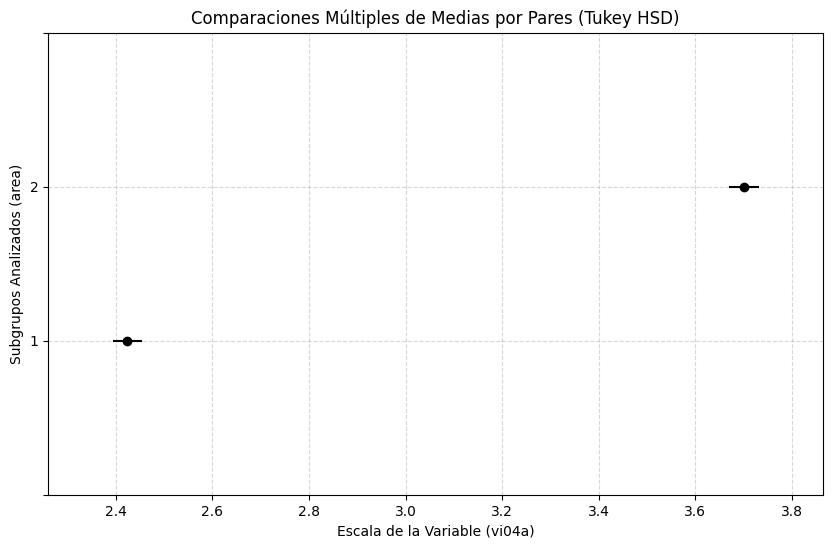

In [4]:
# 1. Filtrado de registros incompletos
df_clean = df[['vi04a', 'area']].dropna()

# 2. Computación de comparaciones múltiples de Tukey HSD
tukey_result = pairwise_tukeyhsd(endog=df_clean['vi04a'],
                                 groups=df_clean['area'],
                                 alpha=0.05)

print("=== MATRIZ COMPARATIVA POST-HOC DE TUKEY ===")
print(tukey_result.summary())

# 3. Generación gráfica de intervalos de confianza
fig, ax = plt.subplots(figsize=(6, 4))
tukey_result.plot_simultaneous(ax=ax)
ax.set_title("Comparaciones Múltiples de Medias por Pares (Tukey HSD)")
ax.set_xlabel("Escala de la Variable (vi04a)")
ax.set_ylabel("Subgrupos Analizados (area)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Conclusiones e Implicaciones Regionales

* **Conclusión de la Prueba Unimuestral (T-Test):** Como el valor-p obtenido es prácticamente cero (mucho menor a nuestro $\alpha = 0.05$), rechazamos con total seguridad la hipótesis nula ($H_0$). Esto significa que tenemos evidencia estadística de sobra para afirmar que el promedio real de cuartos por vivienda es significativamente distinto al estándar teórico de 3.0 que habíamos planteado como referencia.
* **Conclusión de ANOVA y Tukey:** Al obtener un p-ajustado de 0.0000 y observar que la columna de decisión indica `reject = True`, confirmamos de manera rigurosa que el área geográfica (Urbano vs. Rural) marca una diferencia real en el tamaño y la estructura de las viviendas. Como los intervalos en la gráfica no se superponen en lo absoluto, comprobamos que esta desigualdad entre ambos territorios es estadísticamente significativa.